In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('thyroid_dataset.csv')

In [3]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [4]:
X = df.drop(columns = ['Outlier_label'], axis = 1)
y = df['Outlier_label']

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
clf = IsolationForest(n_estimators=200, contamination='auto', random_state=42)
labels = clf.fit_predict(X_scaled, y)

In [11]:
labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

In [18]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

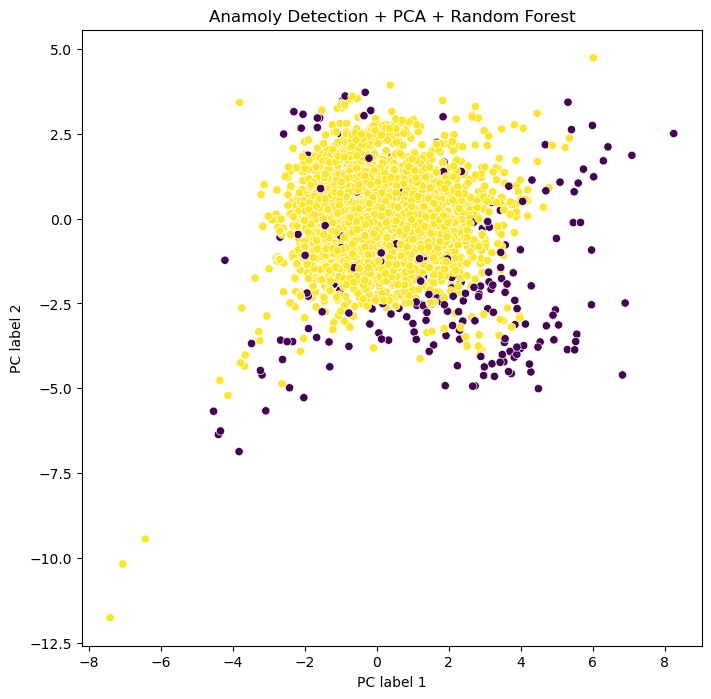

In [24]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x = X_pca[:, 0], y = X_pca[:, 1], c = labels)
plt.xlabel('PC label 1')
plt.ylabel('PC label 2')
plt.title('Anamoly Detection + PCA + Random Forest')
plt.show()

In [27]:
normal = np.sum(labels == 1)
outlier = np.sum(labels == -1)

print(f'The normal data = {normal}')
print(f'Outlier in the data = {outlier}')

The normal data = 6646
Outlier in the data = 270
